In [3]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

In [3]:
df = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly_subset/train.csv")
df.head()

,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


In [4]:
train_data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="item_id",
    timestamp_column="timestamp"
)
train_data.head()

target
item_id timestamp                  
H1      1750-01-01 00:00:00   605.0
        1750-01-01 01:00:00   586.0
        1750-01-01 02:00:00   586.0
        1750-01-01 03:00:00   559.0
        1750-01-01 04:00:00   511.0

In [5]:
predictor = TimeSeriesPredictor(
    prediction_length=48,
    path="autogluon-m4-hourly",
    target="target",
    eval_metric="MASE",
)

predictor.fit(
    train_data,
    presets="medium_quality",
    time_limit=600,
)

Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/workspace/autogluon-m4-hourly'
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.14
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #156~18.04.1-Ubuntu SMP Wed Jan 25 15:56:22 UTC 2023
CPU Count:          64
GPU Count:          2
Memory Avail:       96.52 GB / 125.52 GB (76.9%)
Disk Space Avail:   712.66 GB / 1475.38 GB (48.3%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 48,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'target',
 'time_limit': 600,
 'verbosity': 2}

Inferred time series frequency: 'h'
Provided train_data has 14806

In [6]:
predictions = predictor.predict(train_data)
predictions.head()

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


mean         0.1         0.2         0.3  \
item_id timestamp                                                             
H1      1750-01-30 04:00:00  622.191633  598.352106  606.819926  612.956287   
        1750-01-30 05:00:00  563.195006  537.393103  546.954531  553.249349   
        1750-01-30 06:00:00  521.683860  494.428072  504.041315  511.148866   
        1750-01-30 07:00:00  490.505636  461.721751  471.825645  479.072675   
        1750-01-30 08:00:00  465.746875  435.351538  445.591111  453.185296   

                                    0.4         0.5         0.6         0.7  \
item_id timestamp                                                             
H1      1750-01-30 04:00:00  617.685092  622.191633  626.836042  631.409826   
        1750-01-30 05:00:00  558.428323  563.195006  567.606607  572.418778   
        1750-01-30 06:00:00  516.678754  521.683860  526.831450  532.170242   
        1750-01-30 07:00:00  485.098750  490.505636  496.272718  502.215510   
        1750-01-30 08:00:00  459.950196  465.746875  471.472651  477.611101   

                                    0.8         0.9  
item_id timestamp                                    
H1      1750-01-30 04:00:00  636.792800  644.542990  
        1750-01-30 05:00:00  578.155922  586.702938  
        1750-01-30 06:00:00  538.339783  547.689511  
        1750-01-30 07:00:00  508.974322  519.732682  
        1750-01-30 08:00:00  485.099102  495.941294

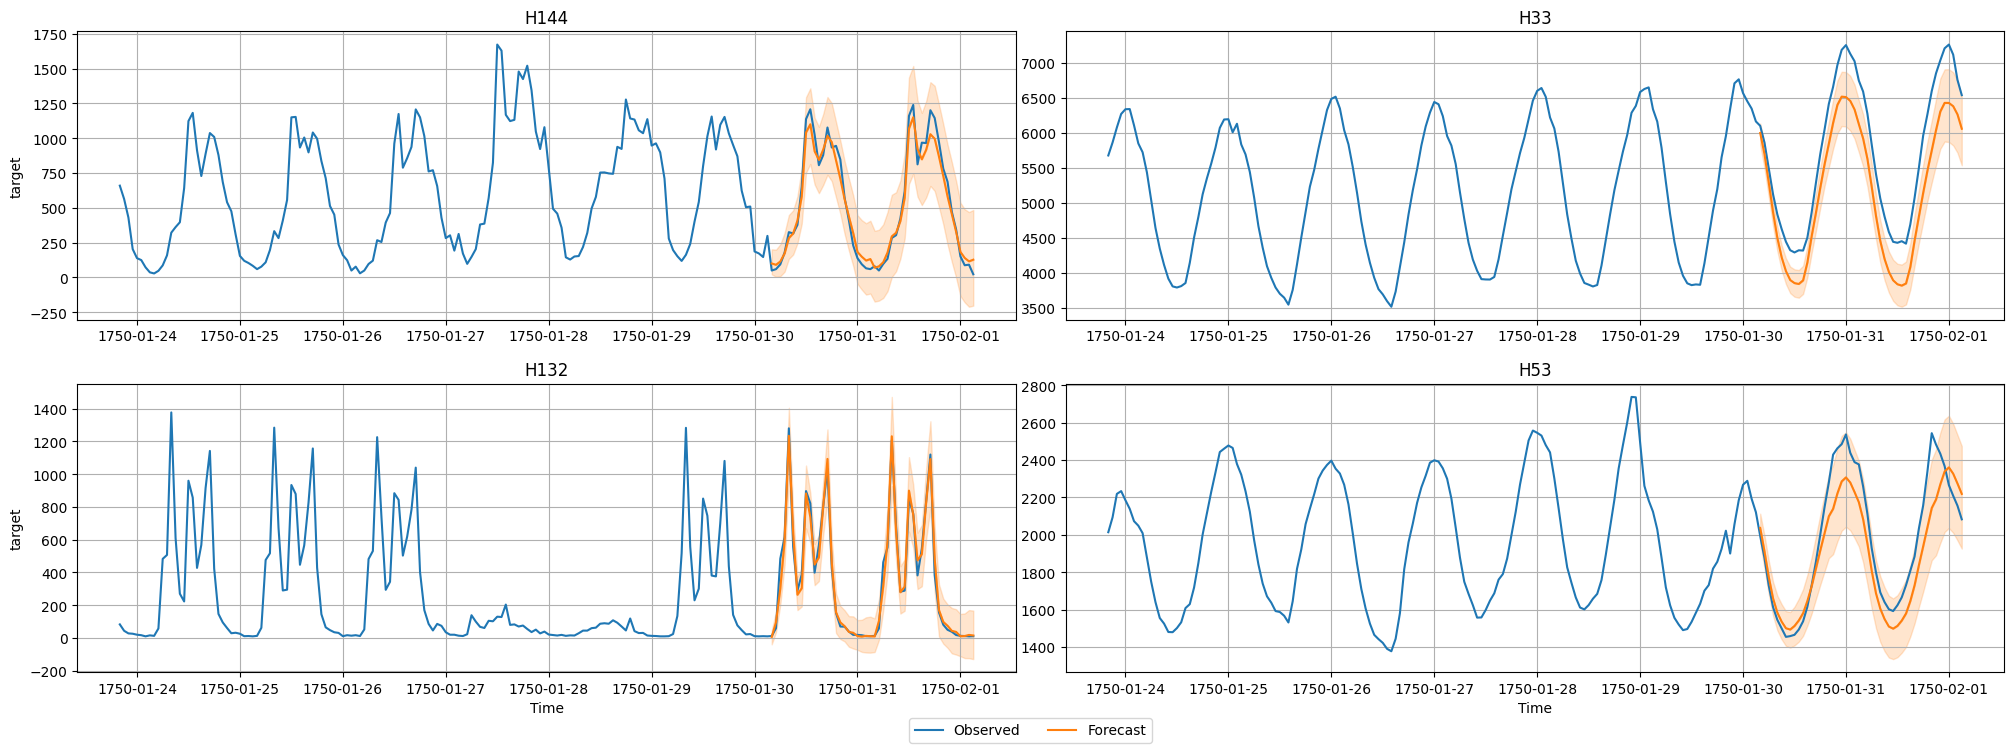

In [7]:
import matplotlib.pyplot as plt

# TimeSeriesDataFrame can also be loaded directly from a file
test_data = TimeSeriesDataFrame.from_path("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly_subset/test.csv")

# Plot 4 randomly chosen time series and the respective forecasts
predictor.plot(test_data, predictions, quantile_levels=[0.1, 0.9], max_history_length=200, max_num_item_ids=4);

In [8]:
# The test score is computed using the last
# prediction_length=48 timesteps of each time series in test_data
predictor.leaderboard(test_data)

Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-0.697903,-0.791454,12.002528,171.081179,0.890381,8
1,Chronos[bolt_small],-0.725739,-0.812070,2.859687,161.213677,2.667898,7
2,RecursiveTabular,-0.862797,-0.933874,1.658165,1.626329,9.937658,3
3,SeasonalNaive,-1.022854,-1.216909,0.252997,0.216407,0.140872,2
4,DirectTabular,-1.605700,-1.292127,0.413468,0.398714,9.275572,4
5,ETS,-1.806131,-1.966061,7.062532,7.842460,0.131297,5
6,Theta,-1.905365,-2.142531,1.188355,46.637036,0.137679,6
7,Naive,-6.696079,-6.662942,0.268805,2.408589,0.154378,1
